In [1]:
from pathlib import Path
DATA_PATH = Path('data.csv')
print('Data path:', DATA_PATH.resolve())

Data path: F:\ML Lab\Lab 7\data.csv


In [2]:
import pandas as pd
import numpy as np
import re, string, os, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import nltk
nltk.download('stopwords')
STOP_WORDS = set(nltk.corpus.stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
with open(DATA_PATH, 'r', encoding='utf-8', errors='ignore') as fh:
    first_line = fh.readline()
df = pd.read_csv(DATA_PATH, names=['label','text'], encoding='utf-8')
print(df.shape)
df.head()

(5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


       count  proportion
label                   
ham     4825    0.865937
spam     747    0.134063


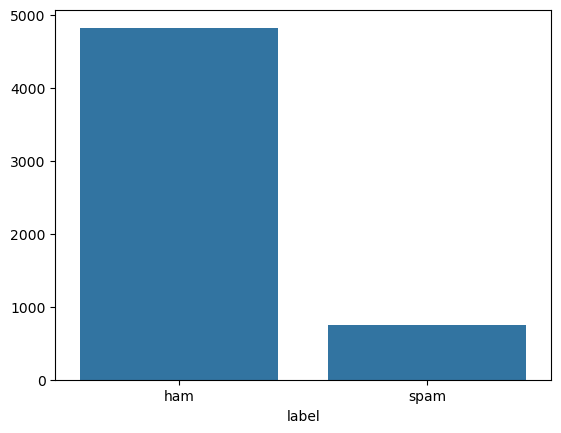

In [4]:
label_counts = df['label'].value_counts()
label_props = df['label'].value_counts(normalize=True)
print(pd.concat([label_counts, label_props], axis=1))

sns.barplot(x=label_counts.index, y=label_counts.values)
plt.show()

In [5]:
PUNCT_TABLE = str.maketrans('', '', string.punctuation)
non_alpha_re = re.compile(r'[^a-z\s]')

def clean_text(s: str) -> str:
    s = s.lower()
    s = s.translate(PUNCT_TABLE)
    s = non_alpha_re.sub(' ', s)
    tokens = [tok for tok in s.split() if tok not in STOP_WORDS]
    if not tokens:
        return '__empty__'
    return ' '.join(tokens)

print(clean_text('FREE entry in 2 a wkly comp!!!'))

free entry wkly comp


In [6]:
df['text'] = df['text'].astype(str)
df['clean'] = df['text'].apply(clean_text)
print('Original -> Cleaned sample:')
print(pd.DataFrame({'orig': df['text'].head(5), 'clean': df['clean'].head(5)}))
print('Unique placeholder count (__empty__):', (df['clean']=='__empty__').sum())

Original -> Cleaned sample:
                                                orig  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                               clean  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  
Unique placeholder count (__empty__): 6


In [7]:
le = LabelEncoder()
df['y'] = le.fit_transform(df['label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
df[['label','y']].head()

Label mapping: {'ham': 0, 'spam': 1}


,label,y
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [9]:
X = df['clean']
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train size:', len(X_train), 'Test size:', len(X_test))

Train size: 4457 Test size: 1115


In [10]:
count_vectorizer = CountVectorizer(ngram_range=(1,2), min_df=2)
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
print('Count features shape:', X_train_counts.shape)

Count features shape: (4457, 7377)


## BernoulliNB Training (Binary Count Features)

In [11]:
X_train_bin = (X_train_counts > 0).astype(int)
X_test_bin = (X_test_counts > 0).astype(int)
bernoulli_clf_counts = BernoulliNB(alpha=1.0)
bernoulli_clf_counts.fit(X_train_bin, y_train)
bern_counts_pred = bernoulli_clf_counts.predict(X_test_bin)

## MultinomialNB Training (Count Features)

In [12]:
multinomial_clf_counts = MultinomialNB(alpha=1.0)
multinomial_clf_counts.fit(X_train_counts, y_train)
multi_counts_pred = multinomial_clf_counts.predict(X_test_counts)

In [13]:
def evaluate(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }



In [14]:
results = []
bern_counts_metrics = evaluate(y_test, bern_counts_pred)
bern_counts_metrics.update({'model':'BernoulliNB','features':'Count(binary)'})
results.append(bern_counts_metrics)
mult_counts_metrics = evaluate(y_test, multi_counts_pred)
mult_counts_metrics.update({'model':'MultinomialNB','features':'Count'})
results.append(mult_counts_metrics)
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
results_df

,accuracy,precision,recall,f1,model,features
1,0.980269,0.970370,0.879195,0.922535,MultinomialNB,Count
0,0.964126,0.990991,0.738255,0.846154,BernoulliNB,Count(binary)
